# Skin Lesion Boundary Detection Using Canny Edge Detection
Pipeline: Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary → Area & Perimeter

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

## Task 1 — Load the images
Streams 5 HAM10000 dermoscopy images from Hugging Face (no uploads, no Kaggle key needed).

README.md:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

['ISIC_0033116_melanocytic_Nevi', 'ISIC_0033760_melanocytic_Nevi', 'ISIC_0033658_melanocytic_Nevi', 'ISIC_0033435_melanocytic_Nevi', 'ISIC_0033430_melanocytic_Nevi']


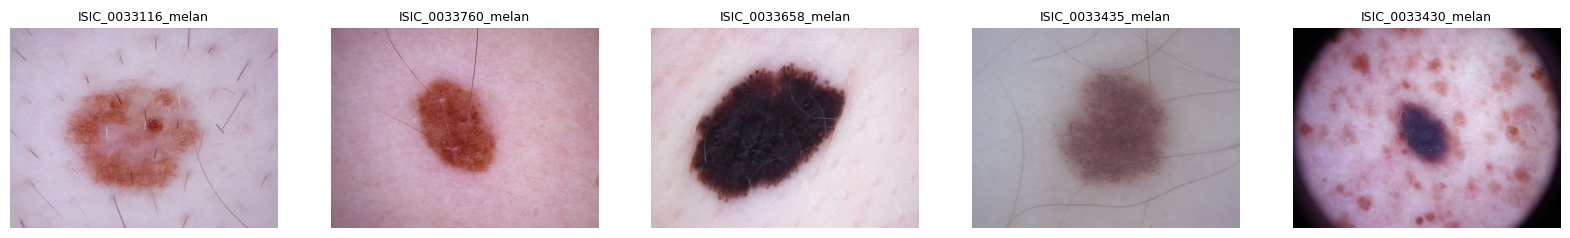

In [2]:
!pip -q install datasets
from datasets import load_dataset

ds = load_dataset("marmal88/skin_cancer", split="train", streaming=True)
ds = ds.shuffle(seed=42, buffer_size=500)     # raw stream is sorted by diagnosis, so shuffle first

N = 5
WANT = "nevi"    # melanocytic nevi = dark lesion on lighter skin, clearest boundaries
paths, images = [], []
for row in ds:
    if WANT not in row["dx"].lower():
        continue
    rgb = np.array(row["image"].convert("RGB"))
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    s = 600 / max(bgr.shape[:2])
    if s < 1:
        bgr = cv2.resize(bgr, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    images.append(bgr)
    paths.append(f"{row['image_id']}_{row['dx']}")
    if len(images) == N:
        break

print(paths)
fig, ax = plt.subplots(1, len(images), figsize=(4*len(images), 4))
for a, im, p in zip(np.atleast_1d(ax), images, paths):
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.set_title(p[:18], fontsize=9); a.axis("off")
plt.show()

## Helper functions

In [3]:
KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

def smooth(gray, kind):
    if kind == "Original": return gray
    if kind == "Average":  return cv2.blur(gray, (5, 5))
    if kind == "Gaussian": return cv2.GaussianBlur(gray, (5, 5), 1.4)
    if kind == "Median":   return cv2.medianBlur(gray, 5)

def sobel_edges(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.convertScaleAbs(np.hypot(gx, gy))
    t, _ = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return ((mag > t) * 255).astype(np.uint8)

def gradient_mag(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.hypot(gx, gy)

def lesion_from_edges(edges):
    """Edges -> closed contour -> filled lesion mask. Returns (mask, contour) or (None, None).
    Tries progressively larger closing kernels so broken edge rings can still be closed."""
    H, W = edges.shape
    for ksz in (7, 15, 25):
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksz, ksz))
        closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k, iterations=2)
        closed = cv2.dilate(closed, k)
        cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        best, best_score = None, 0
        for c in cnts:
            a = cv2.contourArea(c)
            if a < 0.01 * H * W:
                continue
            x, y, w, h = cv2.boundingRect(c)
            touches_border = x <= 2 or y <= 2 or x + w >= W - 2 or y + h >= H - 2
            score = a * (0.3 if touches_border else 1.0)
            if score > best_score:
                best, best_score = c, score
        if best is None:
            continue
        mask = np.zeros((H, W), np.uint8)
        cv2.drawContours(mask, [best], -1, 255, -1)
        mask = cv2.erode(mask, k)
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if cnts:
            return mask, max(cnts, key=cv2.contourArea)
    return None, None

def measure(mask, cnt):
    if mask is None: return 0, 0.0
    return int(cv2.countNonZero(mask)), float(cv2.arcLength(cnt, True))

def boundary_strength(mask, grad):
    """Mean gradient magnitude along the mask boundary (used to auto-pick the best threshold)."""
    if mask is None: return 0.0
    ring = mask - cv2.erode(mask, np.ones((3, 3), np.uint8))
    return float(grad[ring > 0].mean()) if ring.any() else 0.0

## Tasks 2–6 — Run the full pipeline on every image

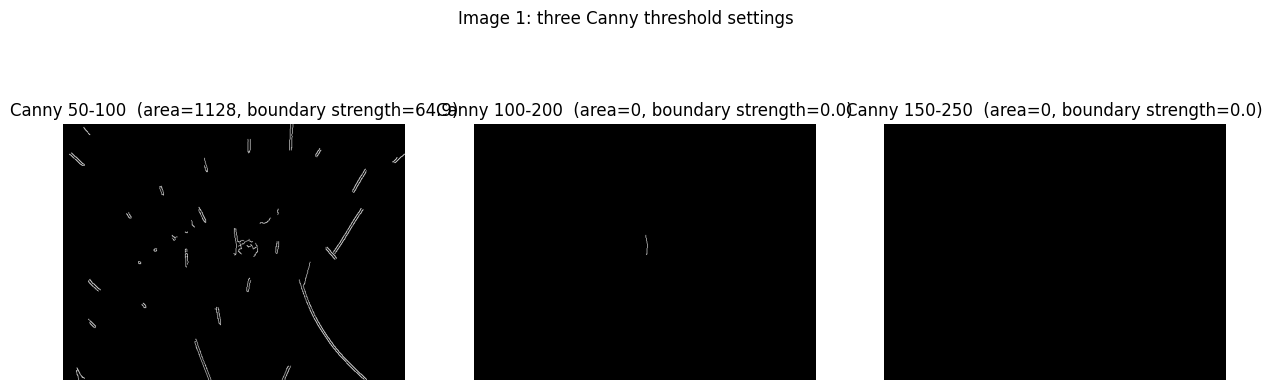

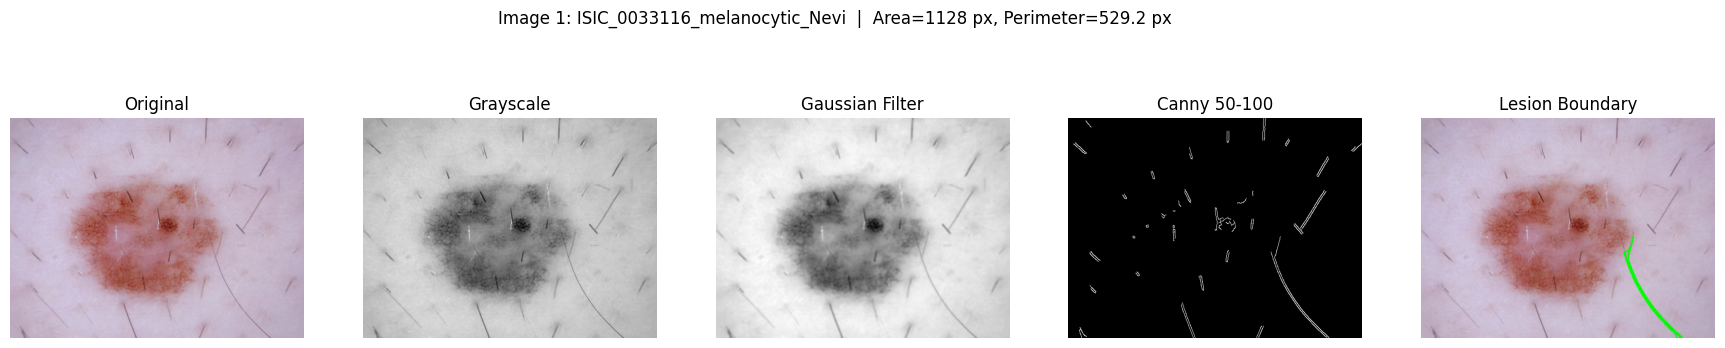

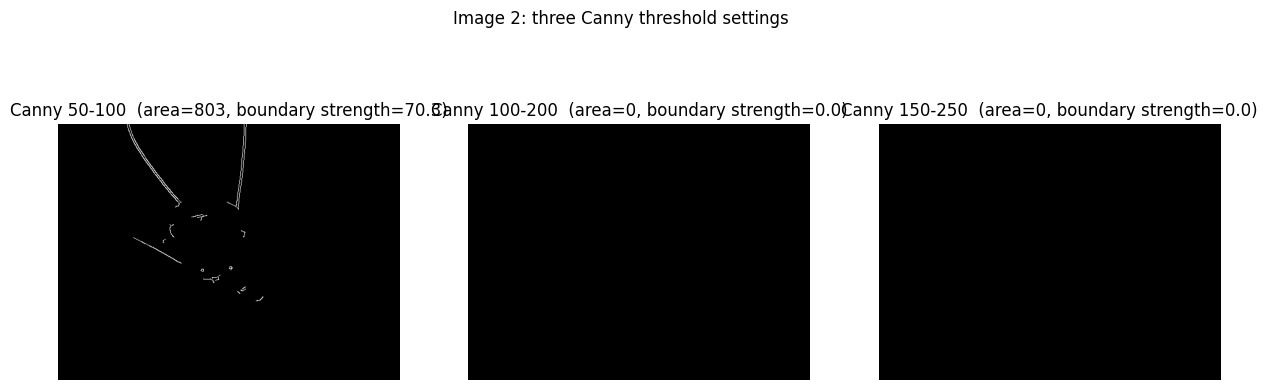

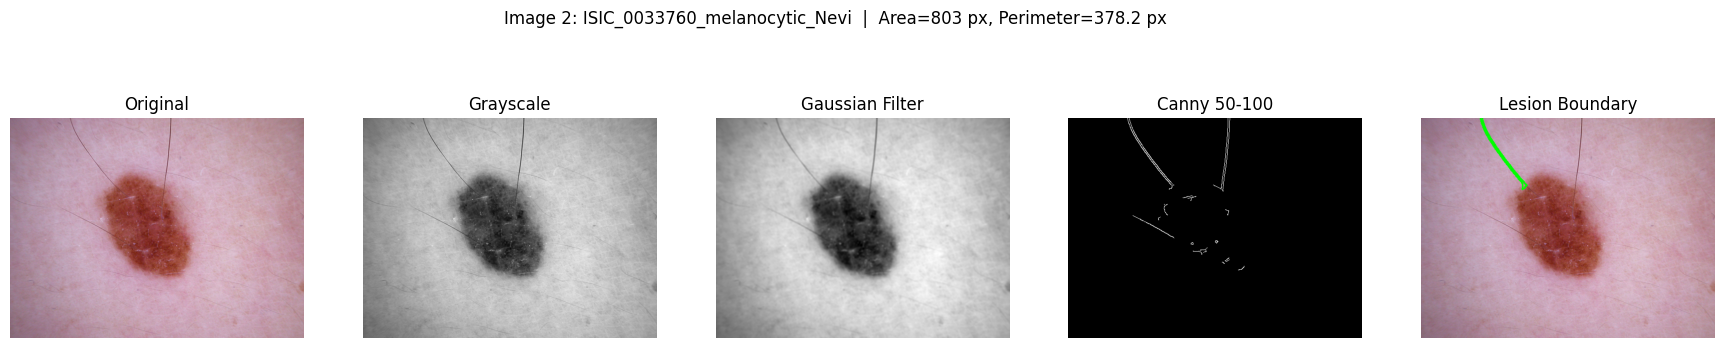

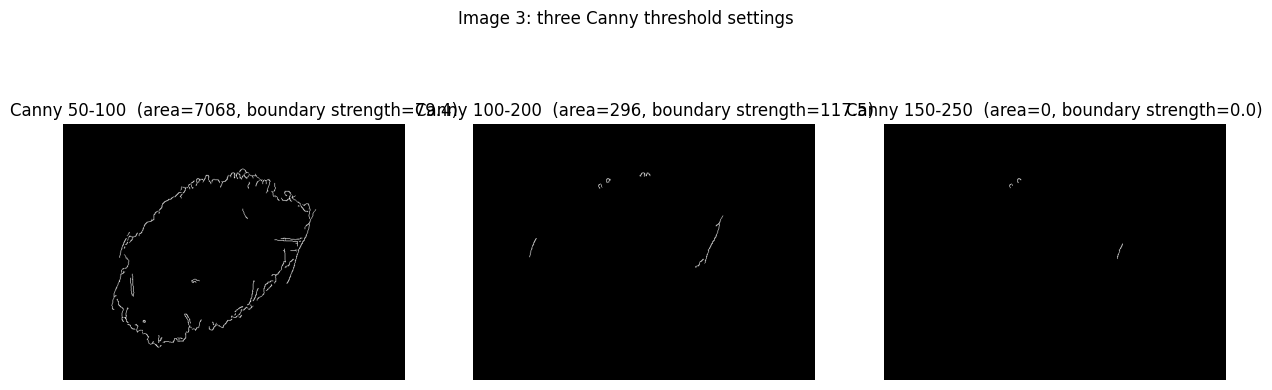

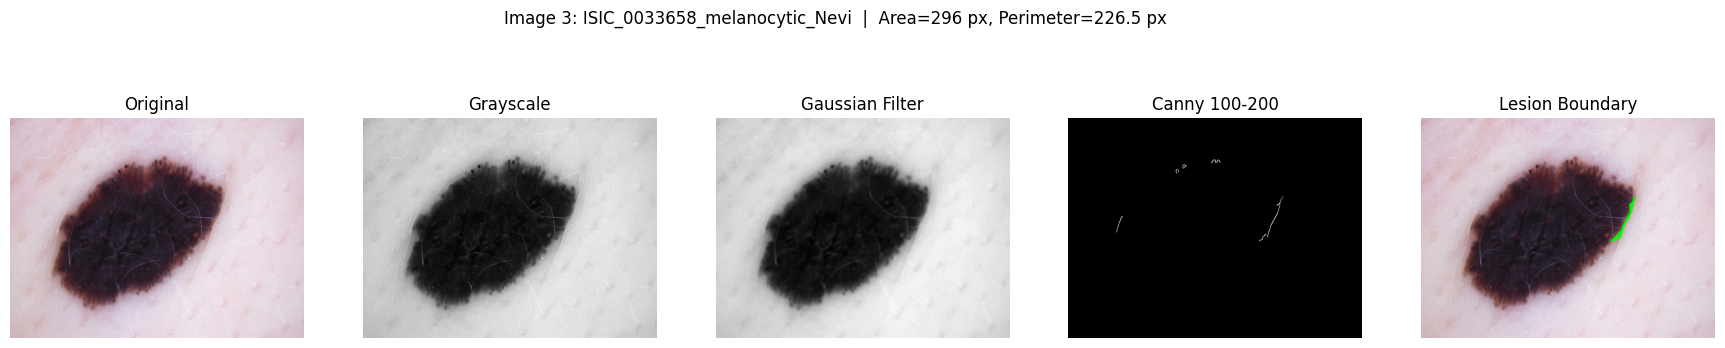

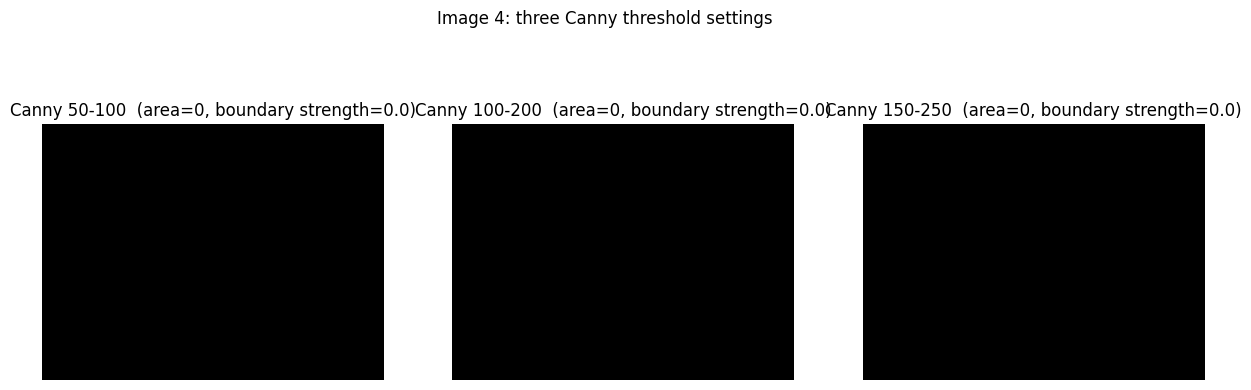

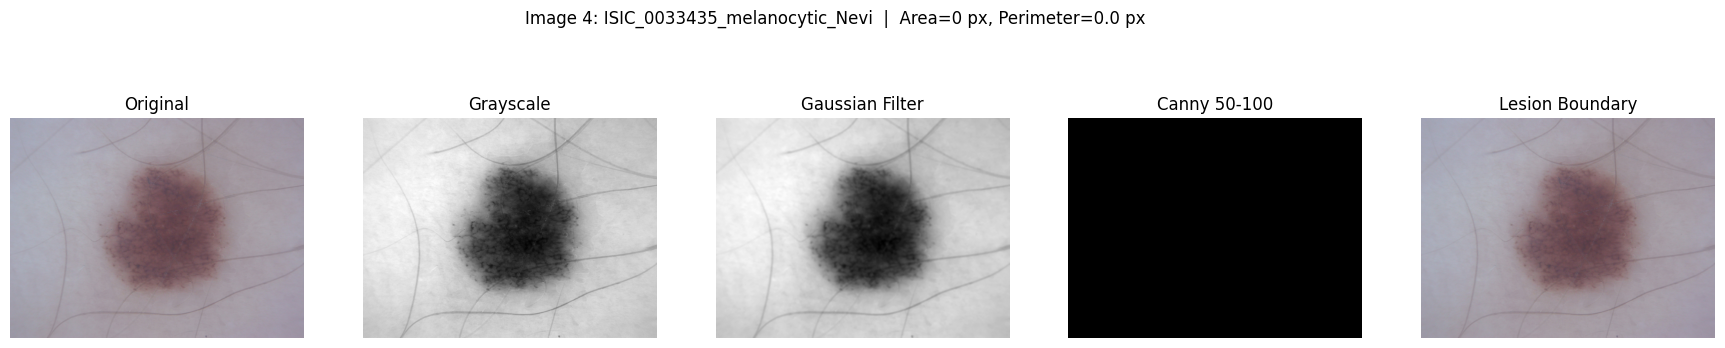

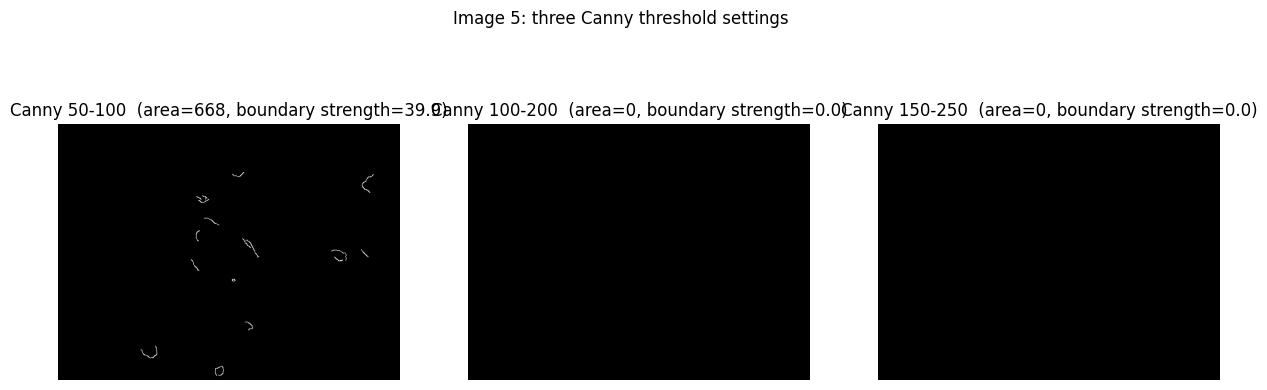

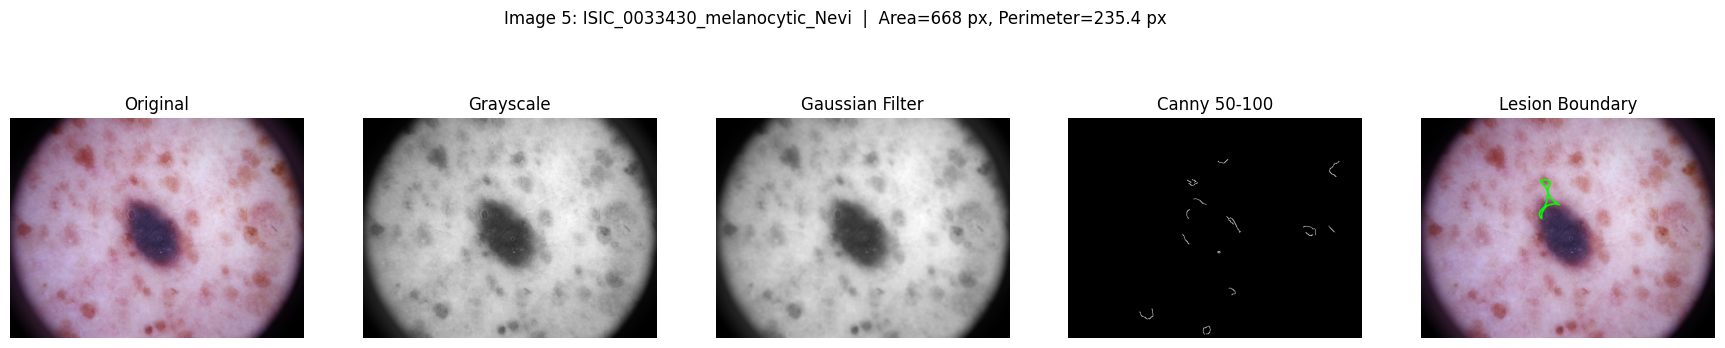

,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian,Canny 50-100,1128,529.2
1,Image 2,Gaussian,Canny 50-100,803,378.2
2,Image 3,Gaussian,Canny 100-200,296,226.5
3,Image 4,Gaussian,Canny 50-100,0,0.0
4,Image 5,Gaussian,Canny 50-100,668,235.4


In [4]:
THRESHOLDS = [(50, 100), (100, 200), (150, 250)]
BEST_OVERRIDE = {}   # manual choice per image index after you inspect the plots, e.g. {0: (100, 200)}

results, best_thr = [], {}

for i, (path, bgr) in enumerate(zip(paths, images)):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gauss = smooth(gray, "Gaussian")
    grad = gradient_mag(gauss)

    # Task 3: three Canny settings
    candidates = []
    for lo, hi in THRESHOLDS:
        e = cv2.Canny(gauss, lo, hi)
        m, c = lesion_from_edges(e)
        area, per = measure(m, c)
        candidates.append(dict(thr=(lo, hi), edges=e, mask=m, cnt=c, area=area, per=per,
                               score=boundary_strength(m, grad)))

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for a, cd in zip(ax, candidates):
        a.imshow(cd["edges"], cmap="gray")
        a.set_title(f"Canny {cd['thr'][0]}-{cd['thr'][1]}  (area={cd['area']}, boundary strength={cd['score']:.1f})")
        a.axis("off")
    plt.suptitle(f"Image {i+1}: three Canny threshold settings"); plt.show()

    # Task 4: best threshold (auto = strongest boundary; override manually if you disagree)
    if i in BEST_OVERRIDE:
        best = next(cd for cd in candidates if cd["thr"] == BEST_OVERRIDE[i])
    else:
        best = max(candidates, key=lambda cd: cd["score"])
    best_thr[i] = best["thr"]

    # Task 5: draw boundary on original
    overlay = bgr.copy()
    if best["cnt"] is not None:
        cv2.drawContours(overlay, [best["cnt"]], -1, (0, 255, 0), 2)

    # Required visualization
    panels = [("Original", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), None),
              ("Grayscale", gray, "gray"),
              ("Gaussian Filter", gauss, "gray"),
              (f"Canny {best['thr'][0]}-{best['thr'][1]}", best["edges"], "gray"),
              ("Lesion Boundary", cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), None)]
    fig, ax = plt.subplots(1, 5, figsize=(22, 4.5))
    for a, (t, im, cm) in zip(ax, panels):
        a.imshow(im, cmap=cm); a.set_title(t); a.axis("off")
    plt.suptitle(f"Image {i+1}: {path}  |  Area={best['area']} px, Perimeter={best['per']:.1f} px")
    plt.show()

    results.append({"Image": f"Image {i+1}", "Best Filter": "Gaussian",
                    "Edge Method": f"Canny {best['thr'][0]}-{best['thr'][1]}",
                    "Area (pixels)": best["area"], "Perimeter (pixels)": round(best["per"], 1)})

results_df = pd.DataFrame(results)
results_df

## Final Comparison — 4 filters × 2 edge detectors
No ground-truth masks are available, so a reference lesion mask is made with inverse Otsu thresholding on the Gaussian-filtered image. Metrics:
- **Noise Handling**: number of tiny isolated edge fragments (fewer = better)
- **Edge Quality**: fraction of edge pixels lying within 3 px of the reference boundary (higher = better)
- **Boundary Detection**: IoU between the detected lesion mask and the reference mask (higher = better)

In [5]:
def reference_mask(gray):
    g = cv2.GaussianBlur(gray, (7, 7), 0)
    _, th = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, KERNEL)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, KERNEL, iterations=2)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    m = np.zeros_like(gray)
    if cnts:
        cv2.drawContours(m, [max(cnts, key=cv2.contourArea)], -1, 255, -1)
    return m

def fragments(edges, min_size=30):
    n, _, stats, _ = cv2.connectedComponentsWithStats(edges, connectivity=8)
    return int(sum(1 for s in stats[1:, cv2.CC_STAT_AREA] if s < min_size))

rows = []
for i, bgr in enumerate(images):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    ref = reference_mask(gray)
    ref_ring = ref - cv2.erode(ref, np.ones((3, 3), np.uint8))
    dist = cv2.distanceTransform(255 - ref_ring, cv2.DIST_L2, 3)
    lo, hi = best_thr[i]

    for filt in ["Original", "Average", "Gaussian", "Median"]:
        sm = smooth(gray, filt)
        for det in ["Sobel", "Canny"]:
            e = sobel_edges(sm) if det == "Sobel" else cv2.Canny(sm, lo, hi)
            m, _ = lesion_from_edges(e)
            inter = cv2.countNonZero(cv2.bitwise_and(m, ref)) if m is not None else 0
            union = cv2.countNonZero(cv2.bitwise_or(m, ref)) if m is not None else cv2.countNonZero(ref)
            rows.append({"Method": f"{filt} + {det}",
                         "Noise (fragments)": fragments(e),
                         "Edge Quality": float((dist[e > 0] <= 3).mean()) if e.any() else 0.0,
                         "Boundary IoU": inter / union if union else 0.0})

order = [f"{f} + {d}" for f in ["Original", "Average", "Gaussian", "Median"] for d in ["Sobel", "Canny"]]
comp = pd.DataFrame(rows).groupby("Method").mean().loc[order]

ranks = pd.DataFrame({
    "n": comp["Noise (fragments)"].rank(ascending=True),
    "q": comp["Edge Quality"].rank(ascending=False),
    "b": comp["Boundary IoU"].rank(ascending=False)})
comp["Overall (mean rank, 1=best)"] = ranks.mean(axis=1)
comp.round(3)

,Noise (fragments),Edge Quality,Boundary IoU,"Overall (mean rank, 1=best)"
Method,,,,
Original + Sobel,1141.8,0.121,0.332,6.667
Original + Canny,122.2,0.140,0.199,5.333
Average + Sobel,319.2,0.180,0.549,3.333
Average + Canny,4.8,0.208,0.001,3.333
Gaussian + Sobel,382.4,0.173,0.534,4.667
Gaussian + Canny,8.4,0.192,0.001,4.333
Median + Sobel,631.8,0.176,0.480,5.000
Median + Canny,14.6,0.265,0.025,3.333


In [6]:
# Save the tables so you can paste them into the report / README
results_df.to_csv("results_table.csv", index=False)
comp.round(3).to_csv("final_comparison.csv")
files.download("results_table.csv")
files.download("final_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>